### Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Display options
pd.set_option("display.max_columns", None)

# Plot settings
plt.style.use("default")
sns.set_theme(style="whitegrid")

### Load Dataset

In [7]:
df = pd.read_csv('../data/raw/heart_disease_data.csv')

In [8]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Dataset Overview

In [9]:
df.shape

(303, 14)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


> Most features are integer type, while oldpeak is float. No obvious datatype inconsistencies are observed.

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


> Cholesterol values vary significantly, suggesting potential outliers.

### Missing Values

In [12]:
missing = df.isnull().sum()
missing_percentage = (missing / len(df)) * 100
missing_percentage

age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64

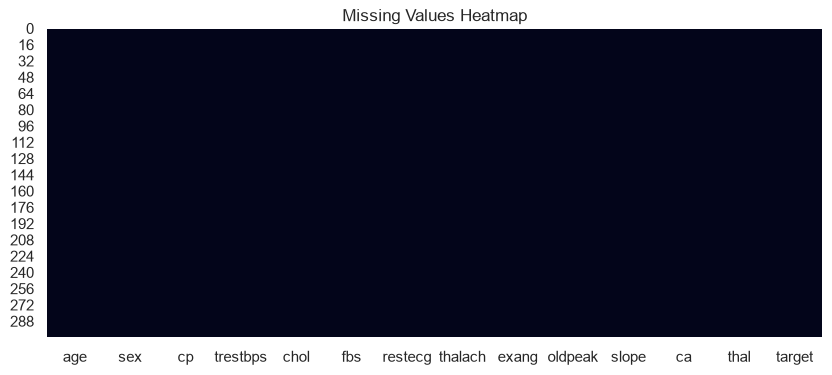

In [13]:
plt.figure(figsize=(10,4))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

> The dataset contains no missing values.

### Duplicate Records

In [14]:
df.duplicated().sum()

np.int64(1)

> No duplicate rows observed

### Target Variable Analysis

In [15]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

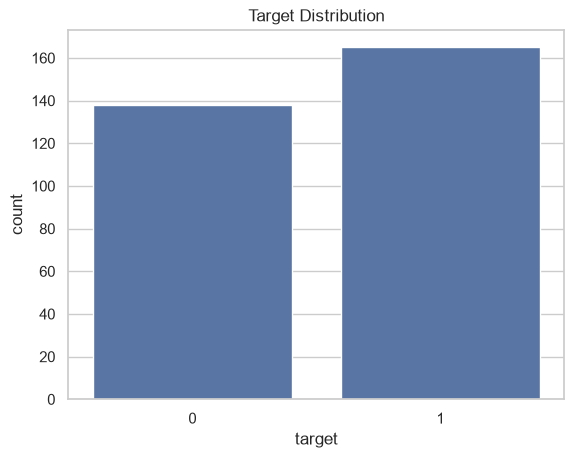

In [16]:
sns.countplot(data=df,x="target")

plt.title("Target Distribution")

plt.show()

In [17]:
df["target"].value_counts(normalize=True)*100

target
1    54.455446
0    45.544554
Name: proportion, dtype: float64

> The dataset is relatively balanced, reducing concerns regarding severe class imbalance.

### Univariate Analysis

In [18]:
# Separate Numerical Columns
numerical_features = [
    'age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca'
]

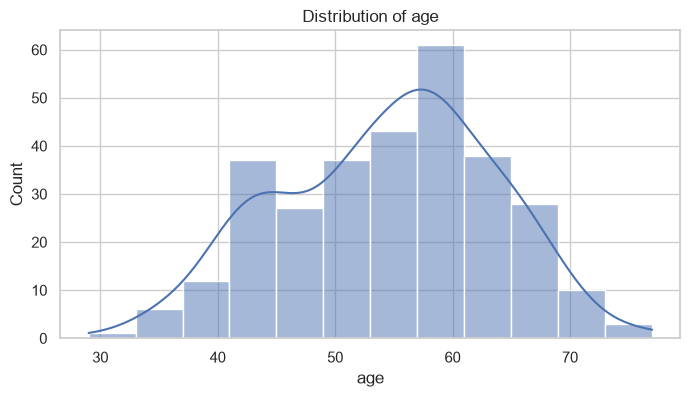

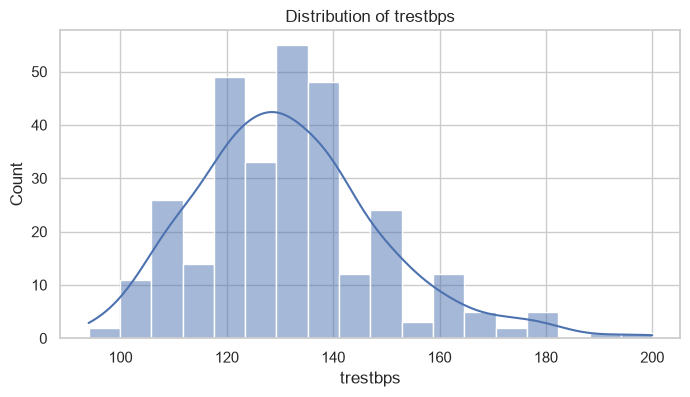

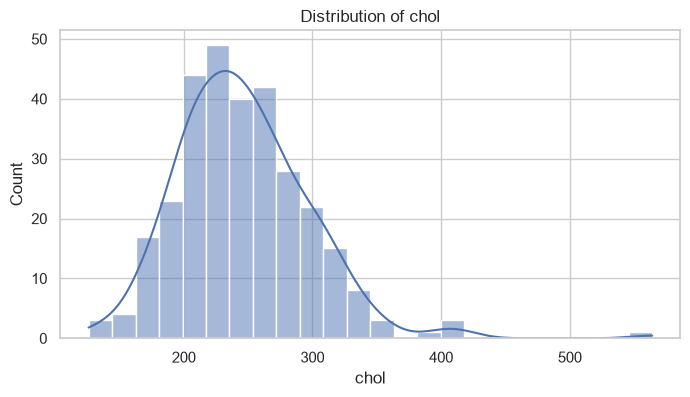

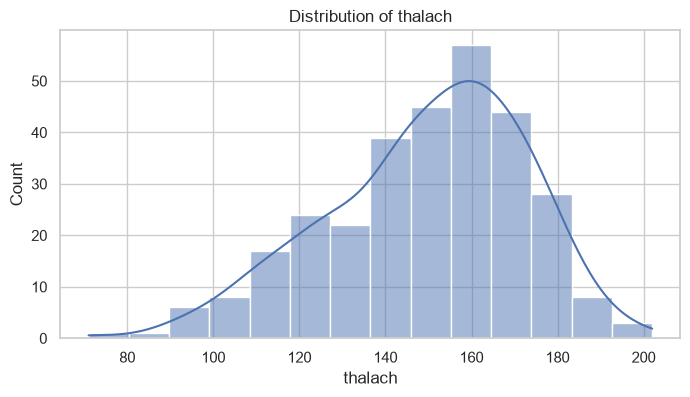

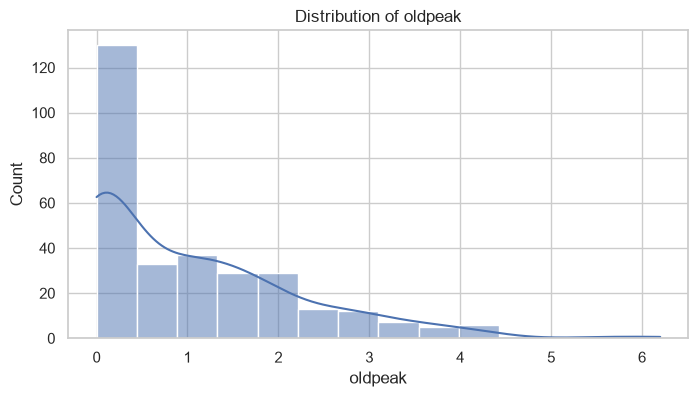

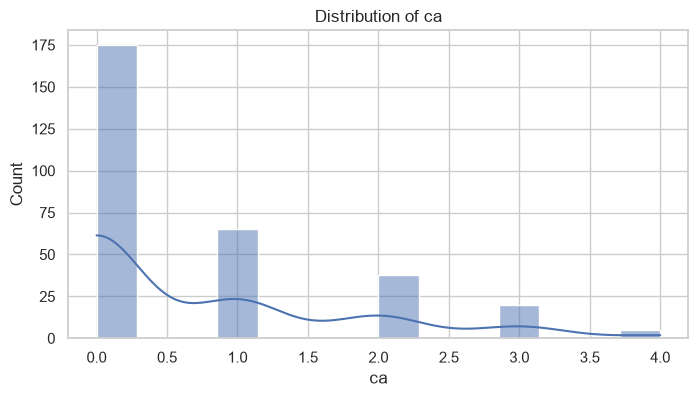

In [19]:
for col in numerical_features:

    plt.figure(figsize=(8,4))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")

    plt.xlabel(col)

    plt.ylabel("Count")

    plt.show()

> Most patients are between 45 and 65 years old. The distribution appears approximately normal with no extreme ages.


> Cholesterol is positively skewed, indicating that a small number of patients have unusually high cholesterol levels.

### Outlier Detection

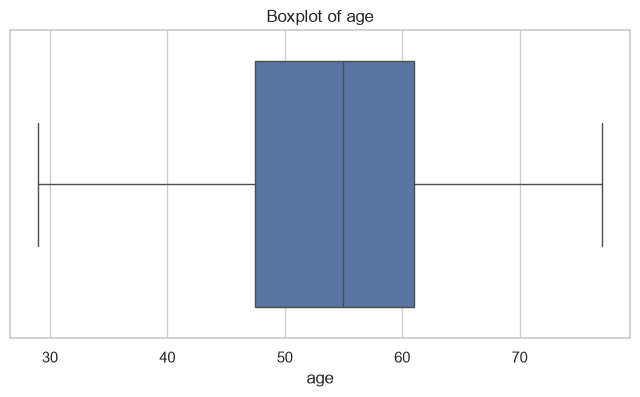

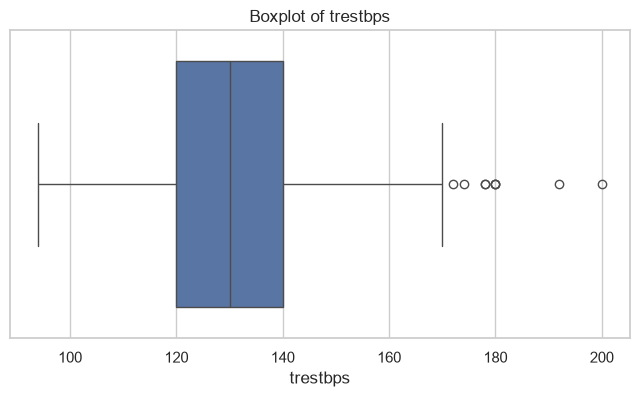

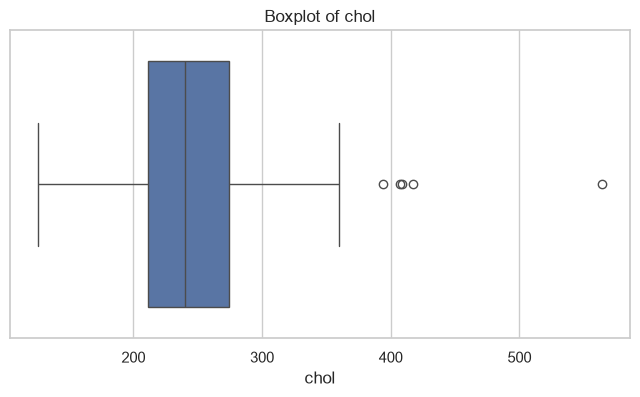

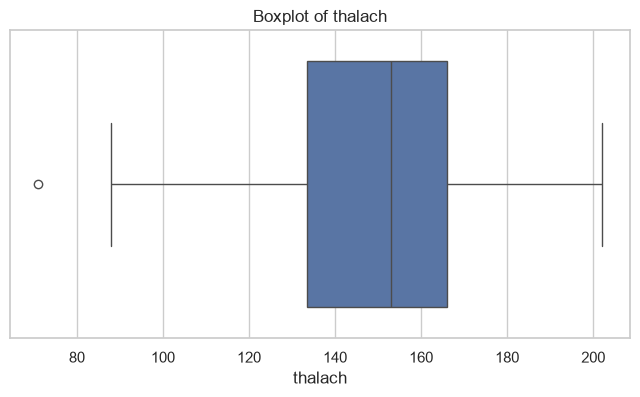

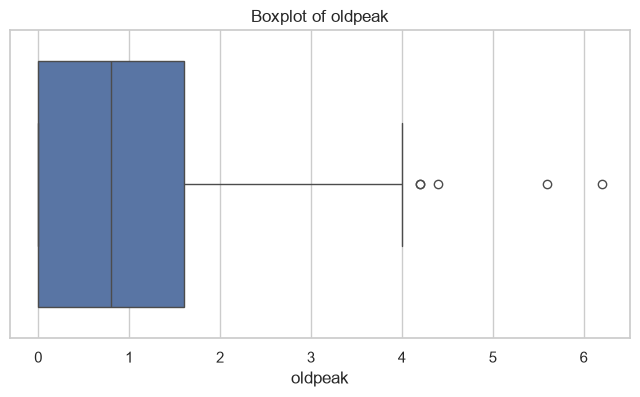

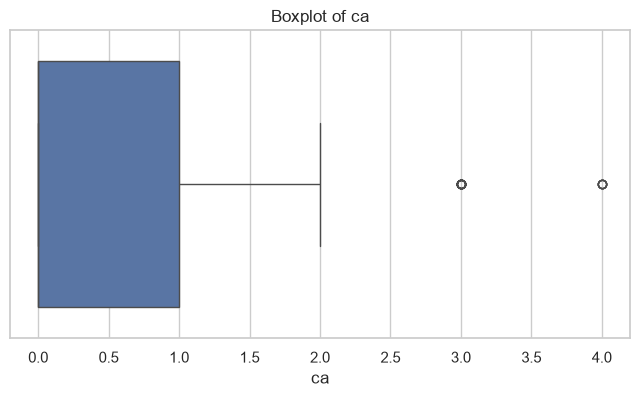

In [20]:
for col in numerical_features:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

In [22]:
# Calculate Outliers (IQR Method)

for col in numerical_features:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
trestbps: 9 outliers
chol: 5 outliers
thalach: 1 outliers
oldpeak: 5 outliers
ca: 25 outliers


### Categorical Feature Analysis

In [23]:
categorical_features = [
    "cp",
    "restecg",
    "slope",
    "thal",
    "sex",
    "fbs",
    "exang"
]

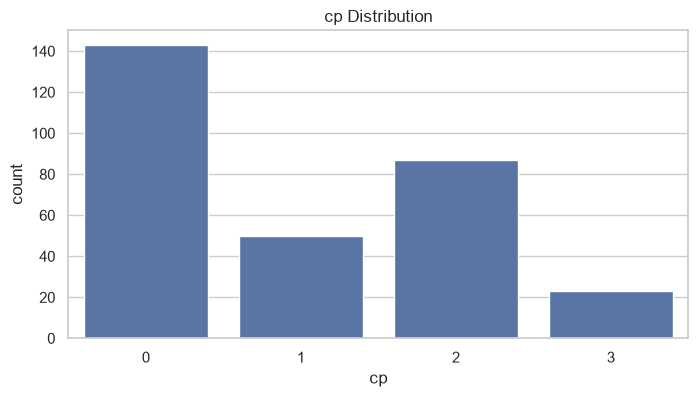

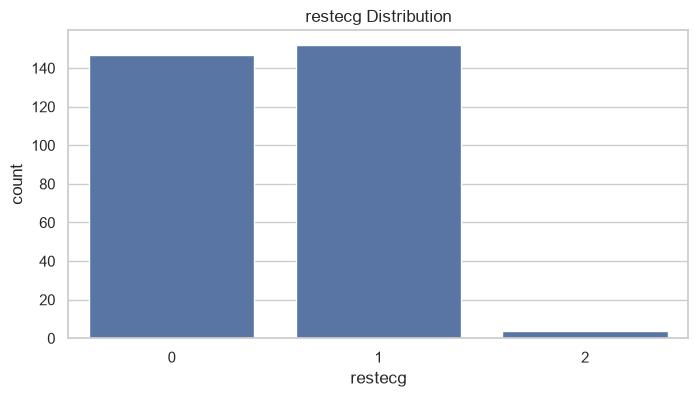

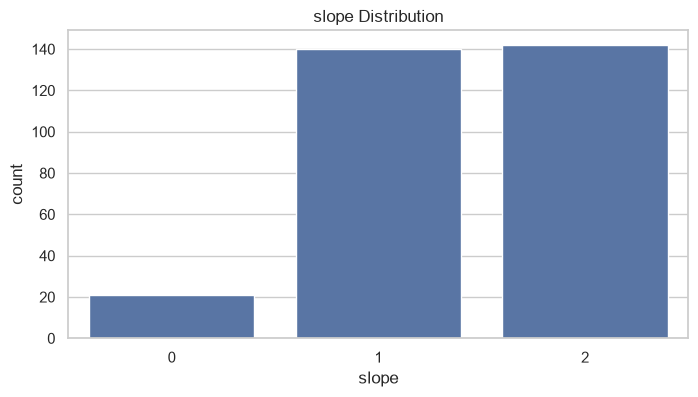

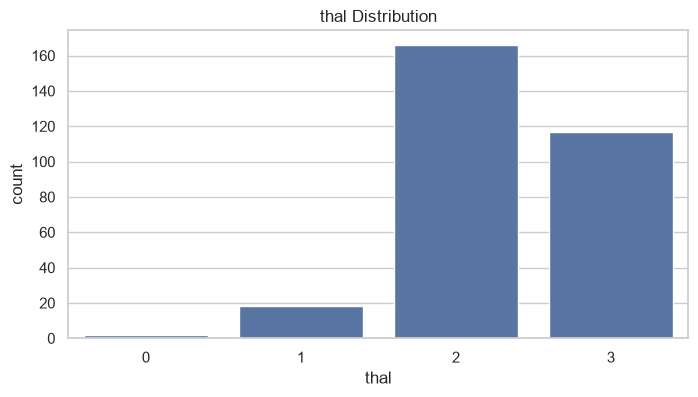

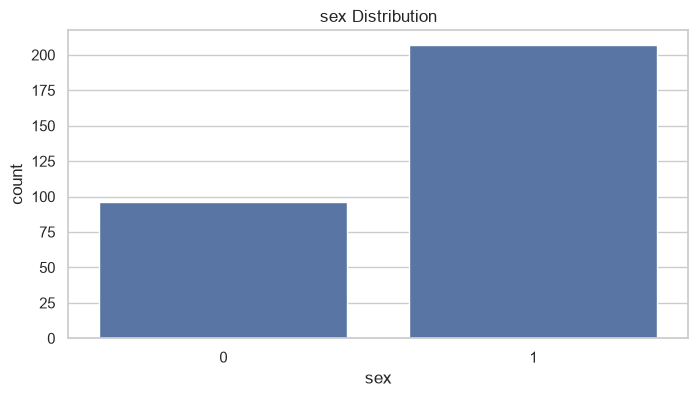

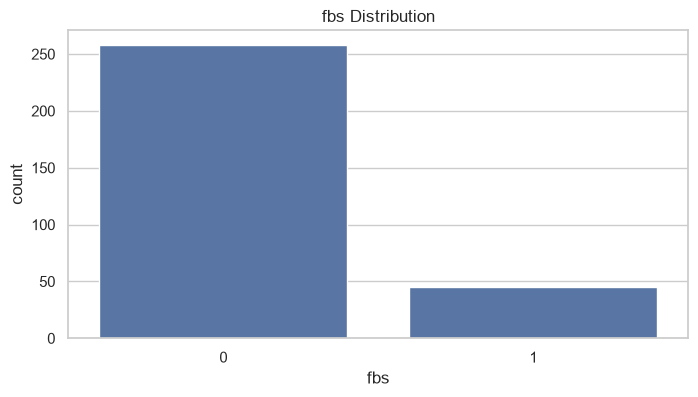

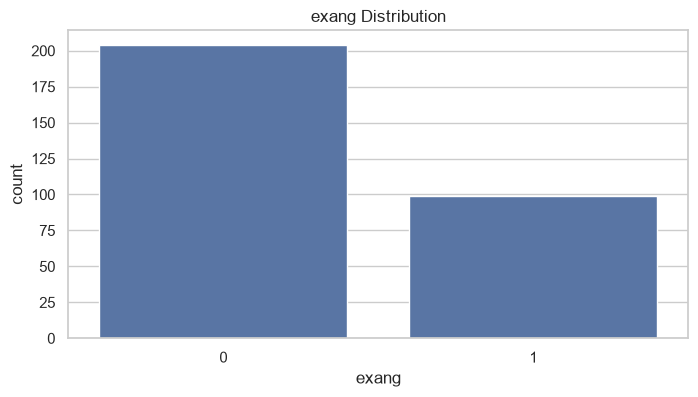

In [24]:
for col in categorical_features:

    plt.figure(figsize=(8,4))

    sns.countplot(data=df, x=col)

    plt.title(f"{col} Distribution")

    plt.show()

### Relationship with Target

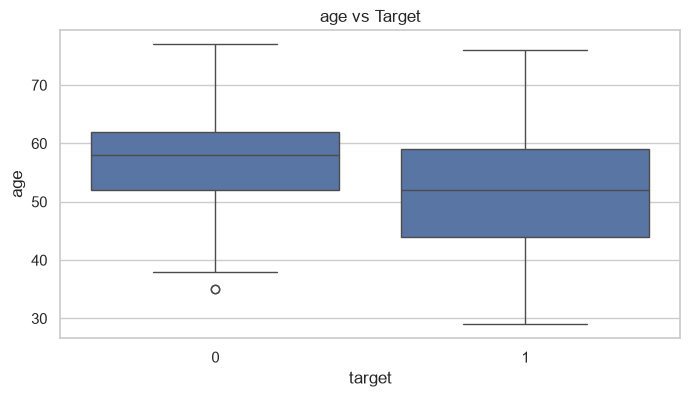

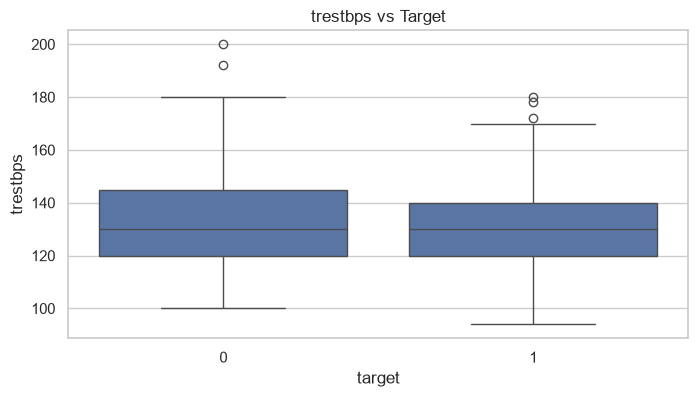

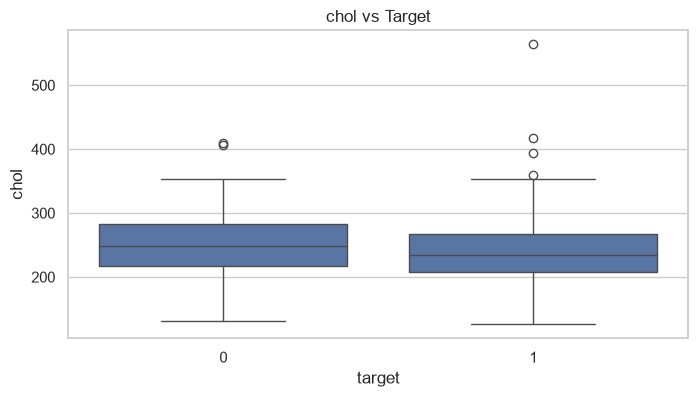

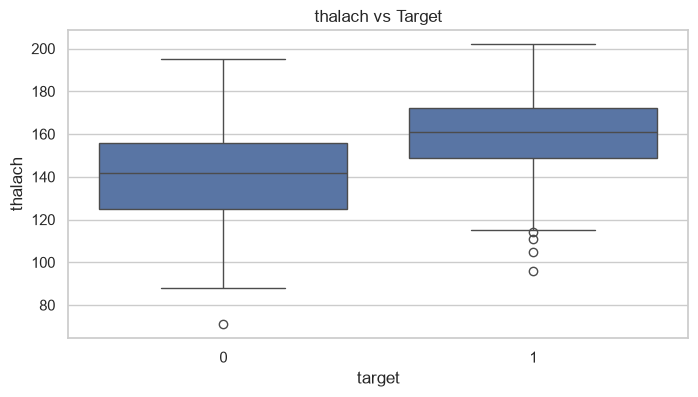

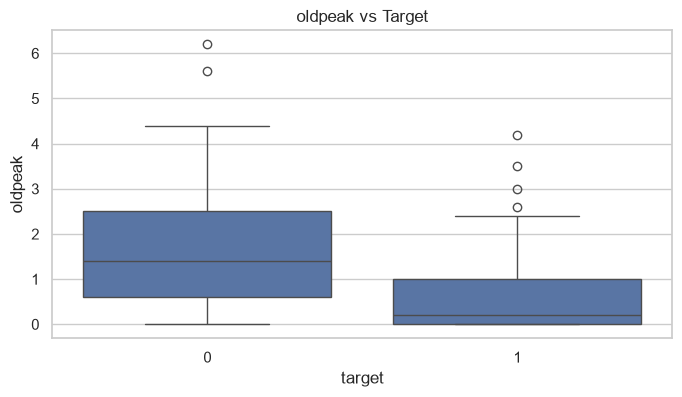

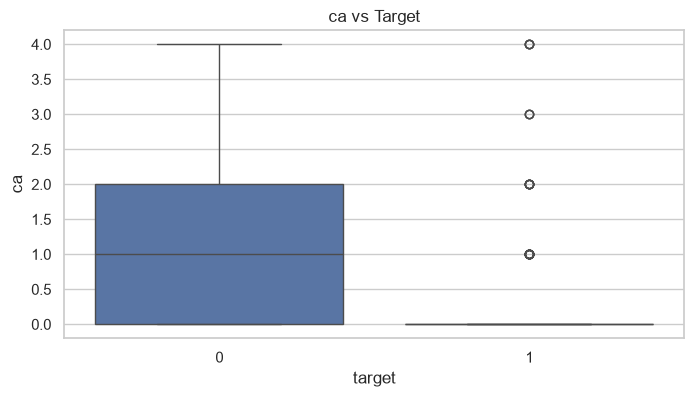

In [27]:
for col in numerical_features:

    plt.figure(figsize=(8,4))

    sns.boxplot(data=df,
                x="target",
                y=col)

    plt.title(f"{col} vs Target")

    plt.show()

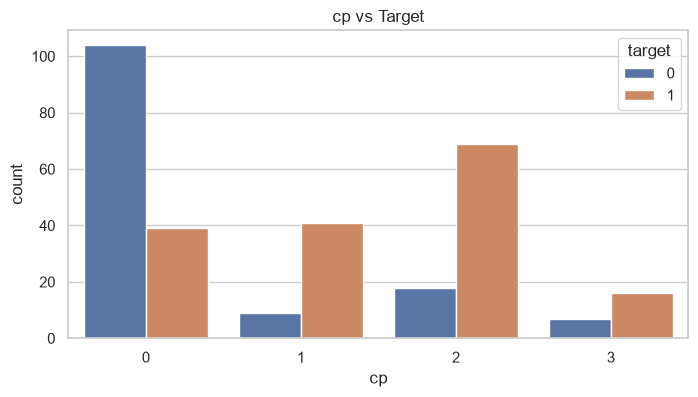

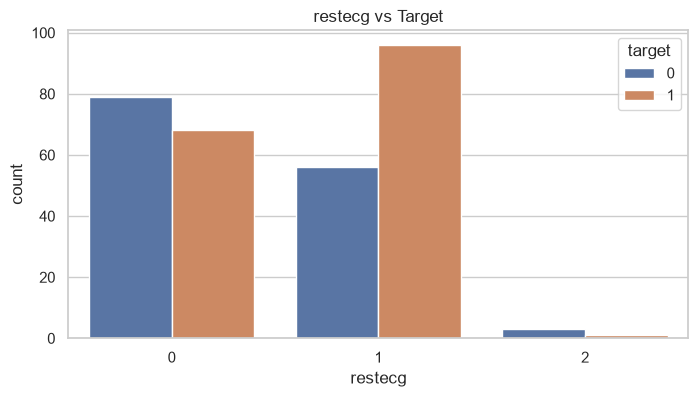

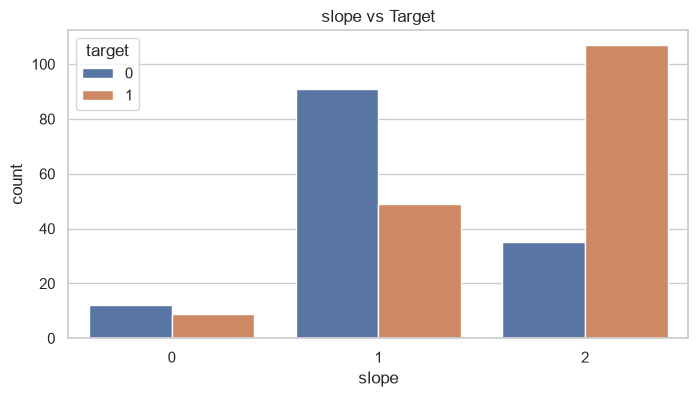

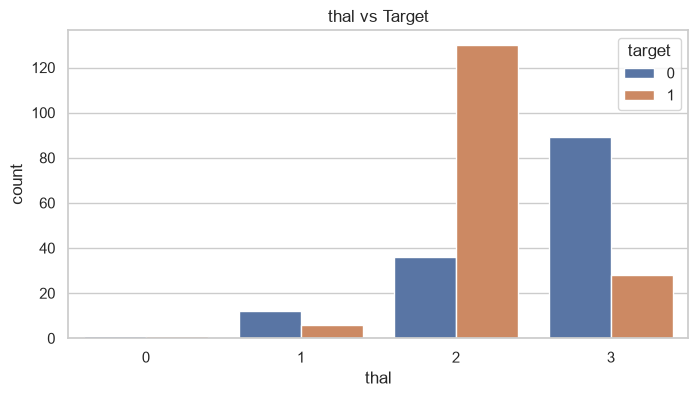

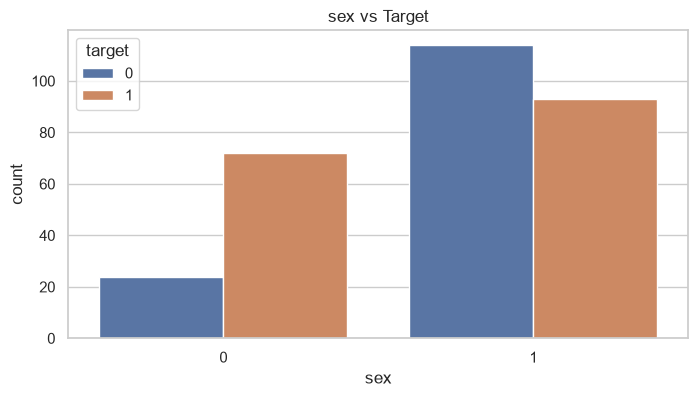

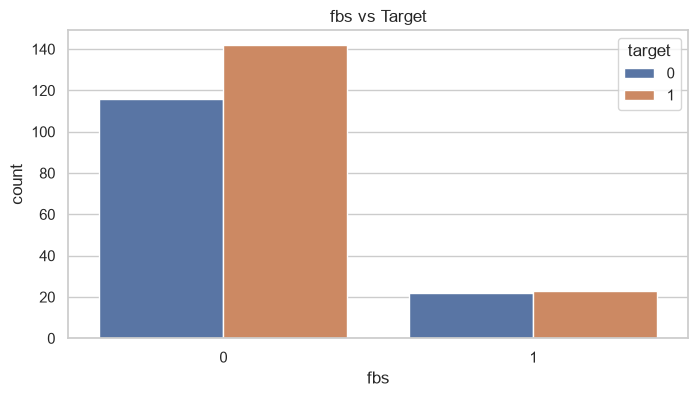

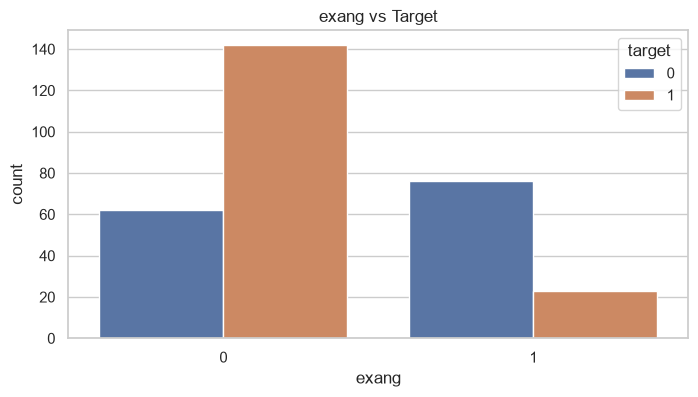

In [28]:
for col in categorical_features:

    plt.figure(figsize=(8,4))

    sns.countplot(data=df,
                  x=col,
                  hue="target")

    plt.title(f"{col} vs Target")

    plt.show()

### Correlation Analysis

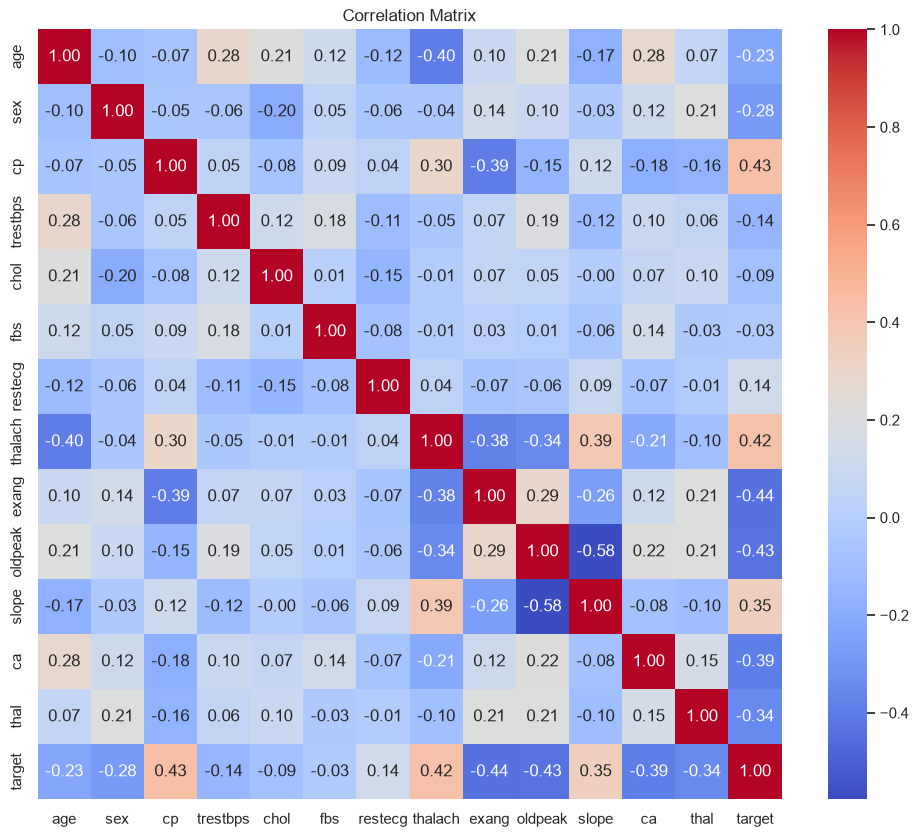

In [29]:
plt.figure(figsize=(12,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### EDA Summary

###### Data Quality
- No missing values detected.
- No duplicate records found.
- Data types are appropriate.

###### Distribution
- Numerical features exhibit varying distributions.
- Cholesterol and oldpeak show positive skewness.
###### Outliers
- Outliers exist in cholesterol and resting blood pressure.
- These values may represent genuine medical conditions and will not be removed without justification.
###### Target Variable
- The dataset appears reasonably balanced.
- Accuracy remains useful but recall and F1-score will also be emphasized.
###### Correlation
- Chest pain type/slope/thalch(+corr), cholestrol/fbs(-corr) - to have meaningful relationships with heart disease.